# 안면 감정 6분류 모델 구현
## EfficientNetB0 기반 전이학습 · FER2013 이미지 데이터셋

---

| 구분 | 이름 |
|:----:|:----:|
| **팀장** | 이지수 |
| 팀원 | 진민경 |
| 팀원 | 김성일 |
| 팀원 | 박효준 |
| 팀원 | 신우철 |

---

## 1. 프로젝트 개요

### 목표
얼굴 이미지로부터 **6가지 감정**을 자동으로 분류하는 딥러닝 모델 개발

### 감정 클래스 구성

| # | 한국어 | 영어 (폴더명) | Train | Test |
|:--:|:------:|:------------:|:-----:|:----:|
| 1 | 기쁨 | happy | 7,215 | 1,774 |
| 2 | 당황 | surprise | 3,171 | 831 |
| 3 | 분노 | angry | 3,995 | 958 |
| 4 | 불안 | fear | 4,097 | 1,024 |
| 5 | 상처 | disgust | 436 | 111 |
| 6 | 슬픔 | sad | 4,830 | 1,247 |
| — | (제외) | neutral | 4,965 | 1,233 |

In [1]:
import sys, platform, subprocess

# 기본 라이브러리 설치
!{sys.executable} -m pip install tensorflow==2.15.0 opencv-python matplotlib seaborn scikit-learn pandas numpy --quiet

# M1/M2/M3 Mac: tensorflow 2.15 + metal 1.1.0 조합만 안정 지원
if platform.machine() == 'arm64' and platform.system() == 'Darwin':
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'show', 'tensorflow'],
        capture_output=True, text=True
    )
    tf_ver = [l for l in result.stdout.splitlines() if l.startswith('Version')]
    tf_ver = tf_ver[0].split(': ')[1].strip() if tf_ver else ''
    if tf_ver == '2.15.0':
        !{sys.executable} -m pip install tensorflow-metal==1.1.0 --quiet
        print(f'GPU 가속 활성화 (tensorflow-metal 1.1.0)')
    else:
        print(f'TF {tf_ver} — tensorflow-metal 미지원, CPU로 실행합니다')
else:
    print('GPU 설정 불필요 (non-Apple Silicon)')

GPU 가속 활성화 (tensorflow-metal 1.1.0)


In [2]:
import os, pickle, platform, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
# Metal(M1/M2) 호환: legacy Adam 사용
try:
    from tensorflow.keras.optimizers.legacy import Adam
except ImportError:
    from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

# Metal 최적화 충돌 방지
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ============================================================
#  GPU / CPU 설정
# ============================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU 사용 : {[g.name for g in gpus]}')
    except RuntimeError as e:
        print(f'GPU 설정 오류 (CPU 사용): {e}')
else:
    print('GPU 없음 — CPU로 실행합니다')
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print(f'TensorFlow : {tf.__version__}')
print(f'아키텍처    : {platform.machine()} / {platform.system()}')

GPU 사용 : ['/physical_device:GPU:0']
TensorFlow : 2.15.0
아키텍처    : arm64 / Darwin


In [3]:
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Linux':
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumBarunGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False
print('폰트 설정 완료')

폰트 설정 완료


In [4]:
# ============================================================
#  경로 설정
# ============================================================
NOTEBOOK_DIR = os.getcwd()
DATA_DIR     = os.path.join(NOTEBOOK_DIR, 'fer2013')
TRAIN_DIR    = os.path.join(DATA_DIR, 'train')
TEST_DIR     = os.path.join(DATA_DIR, 'test')

# ============================================================
#  클래스 설정 (neutral 제외)
# ============================================================
USE_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']

ENG_TO_KOR = {
    'angry':   '분노',
    'disgust': '상처',
    'fear':    '불안',
    'happy':   '기쁨',
    'sad':     '슬픔',
    'surprise': '당황',
}

# flow_from_directory는 알파벳 순 정렬 → index 매핑
# angry=0, disgust=1, fear=2, happy=3, sad=4, surprise=5
IDX_TO_KOR = {i: ENG_TO_KOR[c] for i, c in enumerate(sorted(USE_CLASSES))}
KOR_CLASSES = [IDX_TO_KOR[i] for i in range(len(USE_CLASSES))]

NUM_CLASSES = len(USE_CLASSES)

# ============================================================
#  하이퍼파라미터
# ============================================================
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_P1  = 15
EPOCHS_P2  = 15
LR_P1      = 1e-3
LR_P2      = 1e-4

print(f'데이터 경로    : {DATA_DIR}')
print(f'경로 존재 여부 : {os.path.exists(TRAIN_DIR)}')
print(f'클래스 인덱스  : {IDX_TO_KOR}')
print(f'NUM_CLASSES    : {NUM_CLASSES}')

데이터 경로    : /Users/woochul/github/Expression_detection/안면인식자료/fer2013
경로 존재 여부 : True
클래스 인덱스  : {0: '분노', 1: '상처', 2: '불안', 3: '기쁨', 4: '슬픔', 5: '당황'}
NUM_CLASSES    : 6


## 2. 데이터 탐색 (EDA)

### FER2013 데이터셋
- **출처**: Kaggle FER2013 (msambare)
- **이미지**: 48×48 그레이스케일 JPG
- **구조**: `fer2013/train/{class}/`, `fer2013/test/{class}/`
- **본 프로젝트**: neutral 제외 → 6종 사용

In [5]:
def count_images(base_dir, classes):
    counts = {}
    for cls in classes:
        path = os.path.join(base_dir, cls)
        counts[cls] = len([f for f in os.listdir(path) if f.endswith('.jpg')])
    return counts


train_counts = count_images(TRAIN_DIR, USE_CLASSES)
test_counts  = count_images(TEST_DIR,  USE_CLASSES)

print('클래스별 이미지 수:')
print(f'{"영어":>10}  {"한국어":>6}  {"Train":>6}  {"Test":>5}')
print('-' * 38)
for eng in sorted(USE_CLASSES):
    kor = ENG_TO_KOR[eng]
    print(f'{eng:>10}  {kor:>6}  {train_counts[eng]:>6,}  {test_counts[eng]:>5,}')
print('-' * 38)
print(f'{"합계":>17}  {sum(train_counts.values()):>6,}  {sum(test_counts.values()):>5,}')

클래스별 이미지 수:
        영어     한국어   Train   Test
--------------------------------------
     angry      분노   3,995    958
   disgust      상처     436    111
      fear      불안   4,097  1,024
     happy      기쁨   7,215  1,774
       sad      슬픔   4,830  1,247
  surprise      당황   3,171    831
--------------------------------------
               합계  23,744  5,945


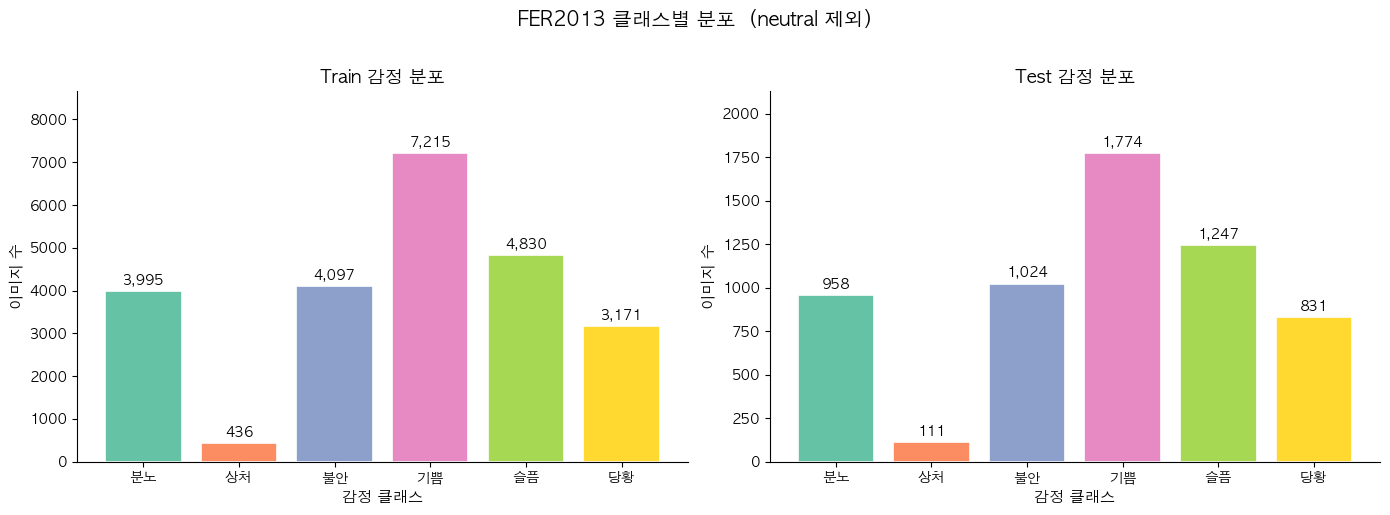


※ disgust(상처) 클래스가 다른 클래스 대비 크게 적어 클래스 불균형 존재


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Train 감정 분포', 'Test 감정 분포']
):
    classes_sorted = sorted(USE_CLASSES)
    kor_labels = [ENG_TO_KOR[c] for c in classes_sorted]
    vals = [counts[c] for c in classes_sorted]

    colors = plt.cm.Set2.colors[:len(classes_sorted)]
    bars = ax.bar(kor_labels, vals, color=colors, edgecolor='white', linewidth=1.2)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('감정 클래스', fontsize=11)
    ax.set_ylabel('이미지 수', fontsize=11)
    ax.set_ylim(0, max(vals) * 1.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('FER2013 클래스별 분포  (neutral 제외)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n※ disgust(상처) 클래스가 다른 클래스 대비 크게 적어 클래스 불균형 존재')

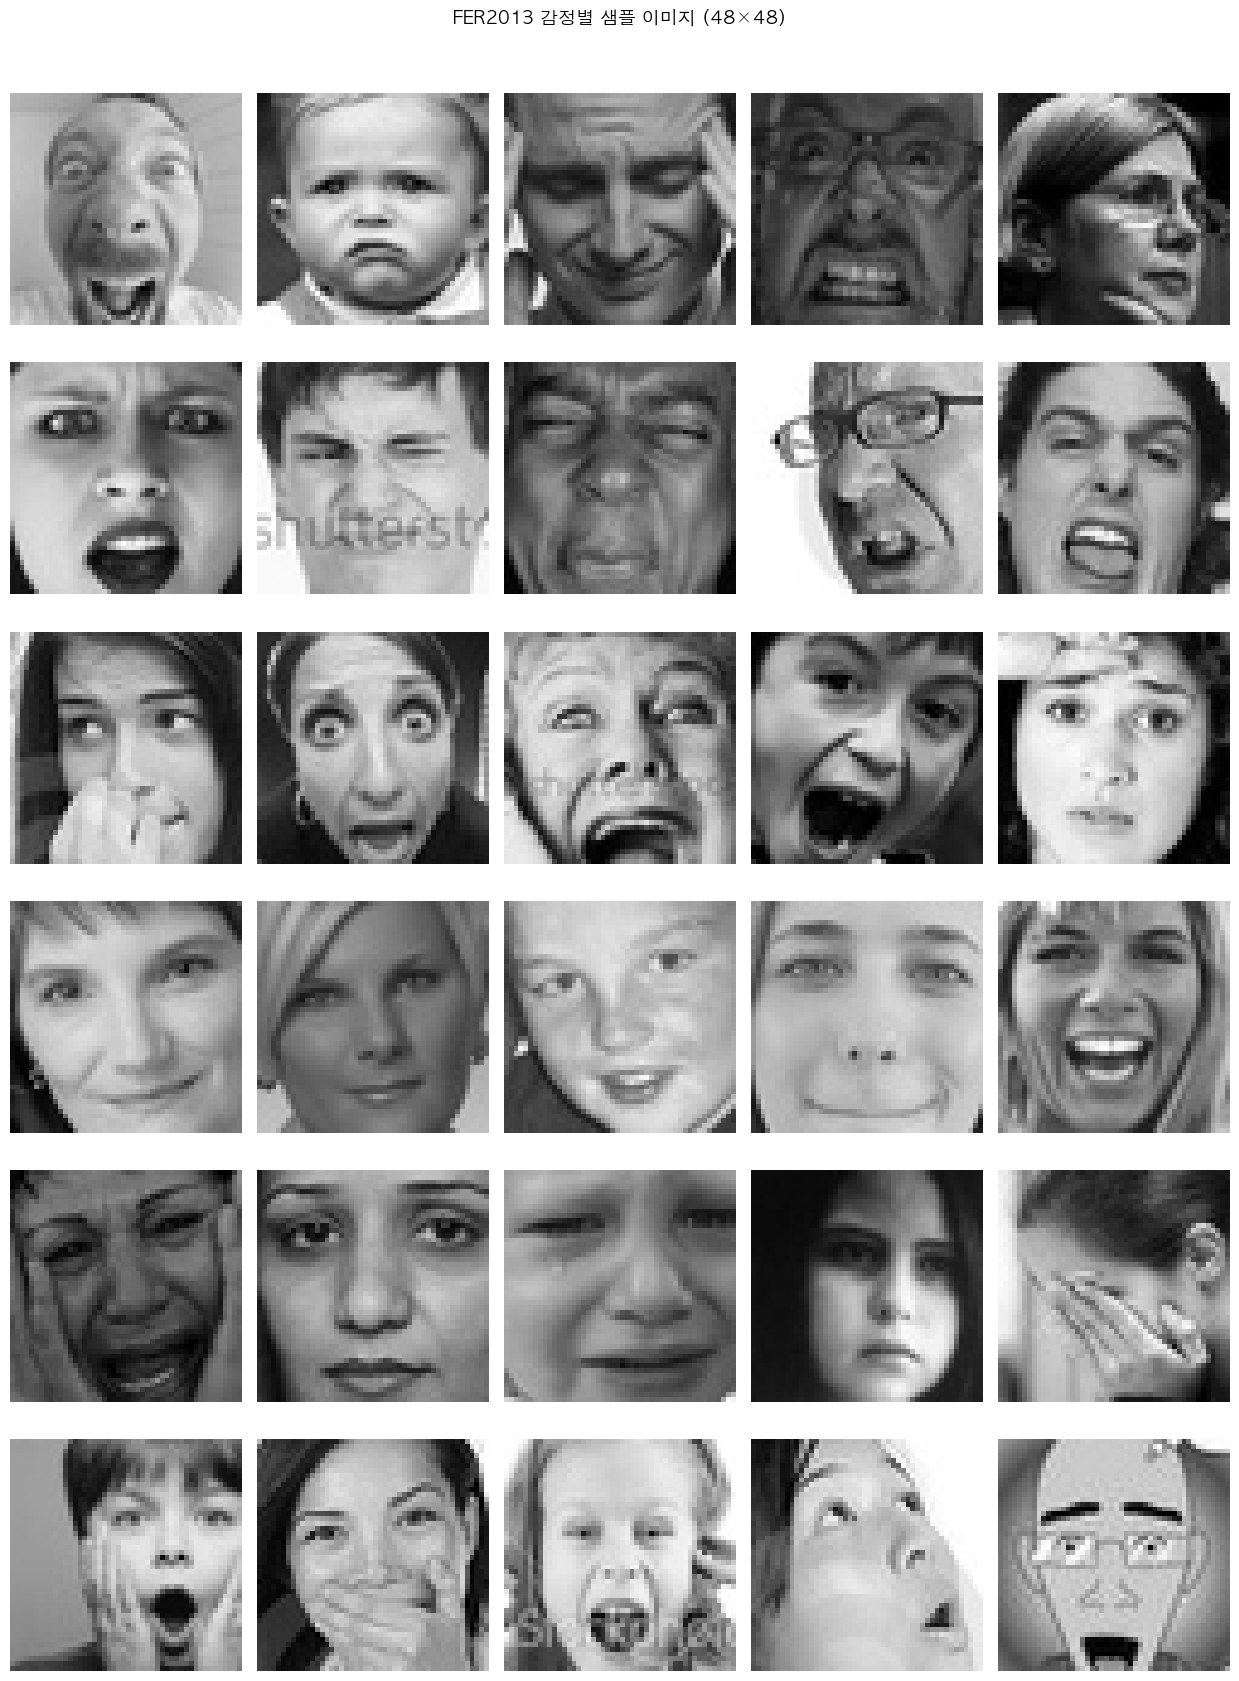

In [7]:
def visualize_samples(base_dir, classes, n_per_class=4):
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 2.5, len(classes) * 2.8))

    for row, eng in enumerate(sorted(classes)):
        class_dir = os.path.join(base_dir, eng)
        files = [f for f in os.listdir(class_dir) if f.endswith('.jpg')][:n_per_class]

        for col, fname in enumerate(files):
            ax = axes[row][col]
            img = cv2.imread(os.path.join(class_dir, fname))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            if col == 0:
                ax.set_ylabel(ENG_TO_KOR[eng], fontsize=12, fontweight='bold',
                              rotation=0, labelpad=40, va='center')
            ax.axis('off')

    plt.suptitle('FER2013 감정별 샘플 이미지 (48×48)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


visualize_samples(TRAIN_DIR, USE_CLASSES, n_per_class=5)

## 3. 전처리 파이프라인

| 단계 | 변환 | 비고 |
|:----:|:----:|:----:|
| 1 | 48×48 JPG 로드 | 그레이스케일이나 BGR 3채널로 저장됨 |
| 2 | RGB 변환 | OpenCV BGR → RGB |
| 3 | 224×224 리사이즈 | EfficientNetB0 입력 크기 |
| 4 | EfficientNetB0 전처리 | 픽셀값 정규화 |
| 5 | 데이터 증강 (Train) | 회전·이동·뒤집기·밝기 |

In [8]:
# Train: 증강 + EfficientNetB0 전처리 + validation split 10%
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True,
    zoom_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.10  # 10% → validation
)

# Test: 전처리만
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=USE_CLASSES,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=USE_CLASSES,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=USE_CLASSES,
    class_mode='categorical',
    shuffle=False
)

# flow_from_directory의 class_indices 확인 후 한국어 매핑 업데이트
ENG_IDX = train_gen.class_indices  # {'angry': 0, 'disgust': 1, ...}
IDX_TO_KOR = {v: ENG_TO_KOR[k] for k, v in ENG_IDX.items()}
KOR_CLASSES = [IDX_TO_KOR[i] for i in range(NUM_CLASSES)]

print(f'class_indices  : {ENG_IDX}')
print(f'한국어 매핑     : {IDX_TO_KOR}')
print(f'Train 배치 수   : {len(train_gen)}')
print(f'Val   배치 수   : {len(val_gen)}')
print(f'Test  배치 수   : {len(test_gen)}')

Found 21372 images belonging to 6 classes.
Found 2372 images belonging to 6 classes.
Found 5945 images belonging to 6 classes.
class_indices  : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'sad': 4, 'surprise': 5}
한국어 매핑     : {0: '분노', 1: '상처', 2: '불안', 3: '기쁨', 4: '슬픔', 5: '당황'}
Train 배치 수   : 668
Val   배치 수   : 75
Test  배치 수   : 186


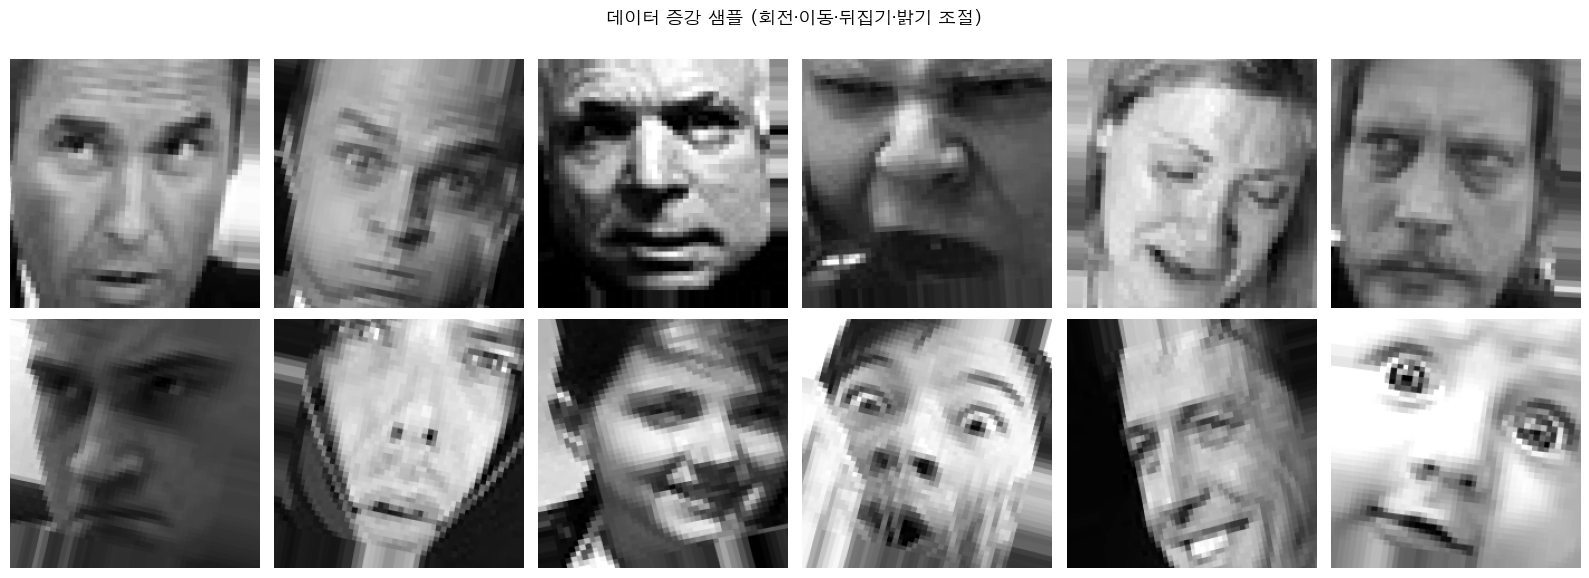

In [9]:
# 증강 결과 시각화
sample_batch, _ = next(train_gen)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    img = sample_batch[i].copy()
    # preprocess_input 역변환 근사 (시각화용)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('데이터 증강 샘플 (회전·이동·뒤집기·밝기 조절)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 모델 구성 — EfficientNetB0

### 모델 선택 근거
EfficientNetB0는 파라미터 수(5.3M)가 적으면서도 ImageNet Top-1 정확도 77.1%를 달성한 경량 고성능 모델로, 본 프로젝트의 제한된 컴퓨팅 환경에 적합합니다.

### 2단계 학습 전략
- **Phase 1**: Base 동결 → FC 레이어만 학습 (LR=1e-3)
- **Phase 2**: 상위 30개 레이어 해제 → Fine-tuning (LR=1e-4)

In [10]:
def build_model(num_classes=NUM_CLASSES, input_shape=IMG_SIZE + (3,)):
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_top')(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.40, name='drop1')(x)
    x = layers.Dense(256, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.30, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs=base.input, outputs=outputs), base


model, base_model = build_model()

total     = model.count_params()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f'전체 파라미터     : {total:,}')
print(f'학습 가능 파라미터: {trainable:,}  (Phase 1 — FC만)')

전체 파라미터     : 4,843,433
학습 가능 파라미터: 791,302  (Phase 1 — FC만)


## 5. 모델 학습

### Phase 1 — Feature Extraction

In [11]:
model.compile(
    optimizer=Adam(learning_rate=LR_P1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1, min_lr=1e-6),
    ModelCheckpoint('best_model_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('Phase 1 : FC 레이어 학습  (Base 모델 동결)')
print('=' * 55)

history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P1,
    callbacks=cb_p1,
    verbose=1
)

Phase 1 : FC 레이어 학습  (Base 모델 동결)
Epoch 1/15
668/668 [==============================] - ETA: 0s - loss: 15.4967 - accuracy: 0.3028
Epoch 1: val_accuracy improved from -inf to 0.30944, saving model to best_model_phase1.keras
668/668 [==============================] - 134s 196ms/step - loss: 15.4967 - accuracy: 0.3028 - val_loss: 27.1978 - val_accuracy: 0.3094 - lr: 0.0010
Epoch 2/15
668/668 [==============================] - ETA: 0s - loss: 55.5364 - accuracy: 0.3200
Epoch 2: val_accuracy did not improve from 0.30944
668/668 [==============================] - 128s 191ms/step - loss: 55.5364 - accuracy: 0.3200 - val_loss: 307.2730 - val_accuracy: 0.1551 - lr: 0.0010
Epoch 3/15
668/668 [==============================] - ETA: 0s - loss: 129.3479 - accuracy: 0.3205
Epoch 3: val_accuracy did not improve from 0.30944
668/668 [==============================] - 128s 192ms/step - loss: 129.3479 - accuracy: 0.3205 - val_loss: 303.9497 - val_accuracy: 0.1994 - lr: 0.0010
Epoch 4/15
668/668 [======

### Phase 2 — Fine-tuning

In [12]:
# 상위 30개 레이어 학습 허용
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

ft_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tune 대상 레이어: {ft_count} / {len(base_model.layers)}')

model.compile(
    optimizer=Adam(learning_rate=LR_P2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('best_model_phase2.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('\n' + '=' * 55)
print('Phase 2 : Fine-tuning  (상위 30개 레이어 학습)')
print('=' * 55)

# Phase 2에서 제너레이터 재시작
train_gen.reset()
val_gen.reset()

history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_P2,
    callbacks=cb_p2,
    verbose=1
)

Fine-tune 대상 레이어: 30 / 238

Phase 2 : Fine-tuning  (상위 30개 레이어 학습)
Epoch 1/15
668/668 [==============================] - ETA: 0s - loss: 6.7095 - accuracy: 0.3885
Epoch 1: val_accuracy improved from -inf to 0.37690, saving model to best_model_phase2.keras
668/668 [==============================] - 136s 193ms/step - loss: 6.7095 - accuracy: 0.3885 - val_loss: 5.2370 - val_accuracy: 0.3769 - lr: 1.0000e-04
Epoch 2/15
668/668 [==============================] - ETA: 0s - loss: 3.8286 - accuracy: 0.3996
Epoch 2: val_accuracy did not improve from 0.37690
668/668 [==============================] - 128s 192ms/step - loss: 3.8286 - accuracy: 0.3996 - val_loss: 6.6358 - val_accuracy: 0.3373 - lr: 1.0000e-04
Epoch 3/15
668/668 [==============================] - ETA: 0s - loss: 3.1399 - accuracy: 0.4051
Epoch 3: val_accuracy did not improve from 0.37690
668/668 [==============================] - 128s 191ms/step - loss: 3.1399 - accuracy: 0.4051 - val_loss: 10.0264 - val_accuracy: 0.3082 - lr: 1.00

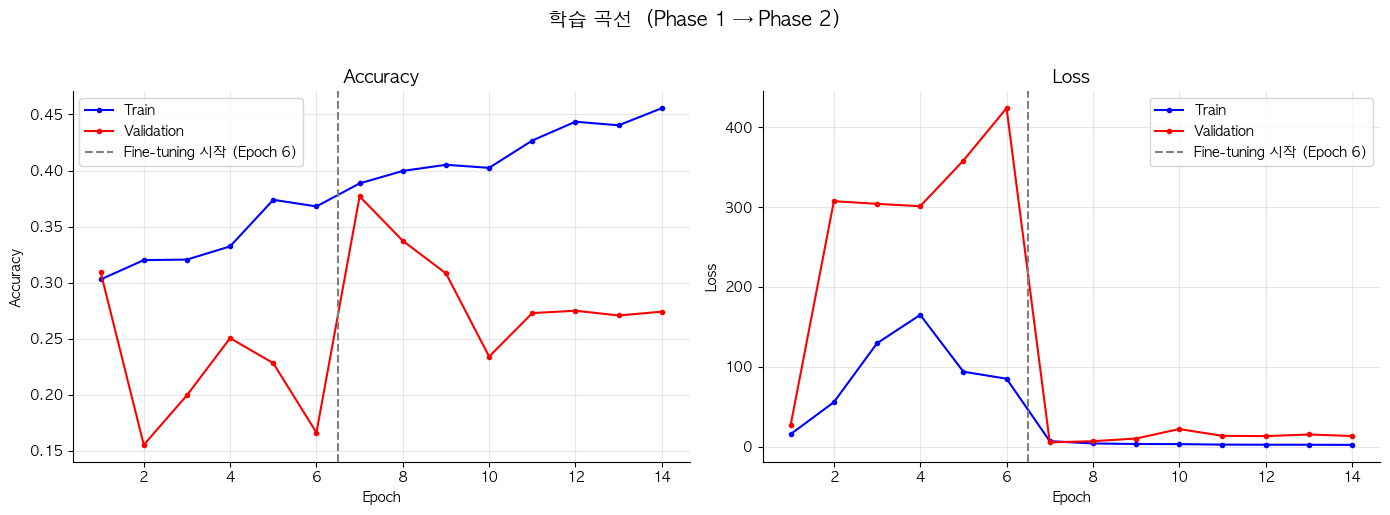

In [13]:
def plot_training_history(h1, h2):
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']         + h2.history['loss']
    vloss= h1.history['val_loss']     + h2.history['val_loss']
    ep   = range(1, len(acc) + 1)
    sep  = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tv, vv, ylabel in zip(
        axes, [acc, loss], [vacc, vloss], ['Accuracy', 'Loss']
    ):
        ax.plot(ep, tv, 'b-o', markersize=3, label='Train')
        ax.plot(ep, vv, 'r-o', markersize=3, label='Validation')
        ax.axvline(x=sep + 0.5, color='gray', linestyle='--', linewidth=1.5,
                   label=f'Fine-tuning 시작 (Epoch {sep})')
        ax.set_title(ylabel, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('학습 곡선  (Phase 1 → Phase 2)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_training_history(history_p1, history_p2)

## 6. 모델 평가

In [14]:
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')

# 전체 예측 수집
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

Test Accuracy : 0.3112  (31.12%)
Test Loss     : 4.5539
186/186 [==============================] - 16s 76ms/step


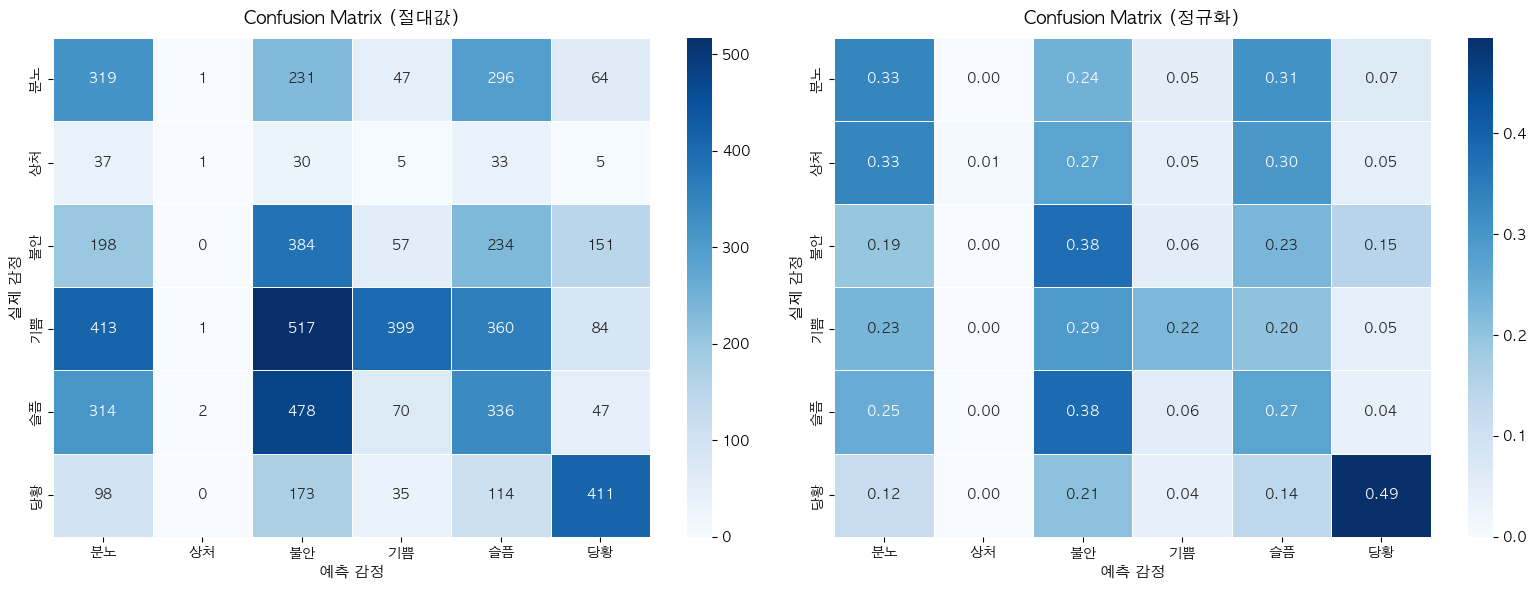

In [15]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (절대값)', 'Confusion Matrix (정규화)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=KOR_CLASSES, yticklabels=KOR_CLASSES,
        linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('예측 감정', fontsize=11)
    ax.set_ylabel('실제 감정', fontsize=11)

plt.tight_layout()
plt.show()

In [16]:
print('=' * 60)
print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred,
                             target_names=KOR_CLASSES, digits=4))

Classification Report
              precision    recall  f1-score   support

          분노     0.2313    0.3330    0.2730       958
          상처     0.2000    0.0090    0.0172       111
          불안     0.2118    0.3750    0.2707      1024
          기쁨     0.6509    0.2249    0.3343      1774
          슬픔     0.2447    0.2694    0.2565      1247
          당황     0.5394    0.4946    0.5160       831

    accuracy                         0.3112      5945
   macro avg     0.3464    0.2843    0.2780      5945
weighted avg     0.3984    0.3112    0.3166      5945



## 7. Grad-CAM 시각화

**Grad-CAM**: 모델이 감정을 예측할 때 **어느 영역에 주목했는지**를 히트맵으로 시각화  
EfficientNetB0 마지막 Conv 레이어(`top_conv`) 그래디언트 활용

In [17]:
LAST_CONV = 'top_conv'

grad_model = Model(
    inputs=model.inputs,
    outputs=[model.get_layer(LAST_CONV).output, model.output]
)


def compute_gradcam(img_array, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        tape.watch(conv_out)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    grads       = tape.gradient(class_score, conv_out)
    pooled_grad = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap     = conv_out[0] @ pooled_grad[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.nn.relu(heatmap)
    heatmap     = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), preds.numpy()[0]


def apply_gradcam_overlay(img_rgb, heatmap, alpha=0.45):
    h = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    h_colored = cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET)
    h_colored = cv2.cvtColor(h_colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_rgb.astype(np.uint8), 1 - alpha,
                           h_colored, alpha, 0)


print(f'Grad-CAM 서브모델 생성 완료 (레이어: {LAST_CONV})')

Grad-CAM 서브모델 생성 완료 (레이어: top_conv)


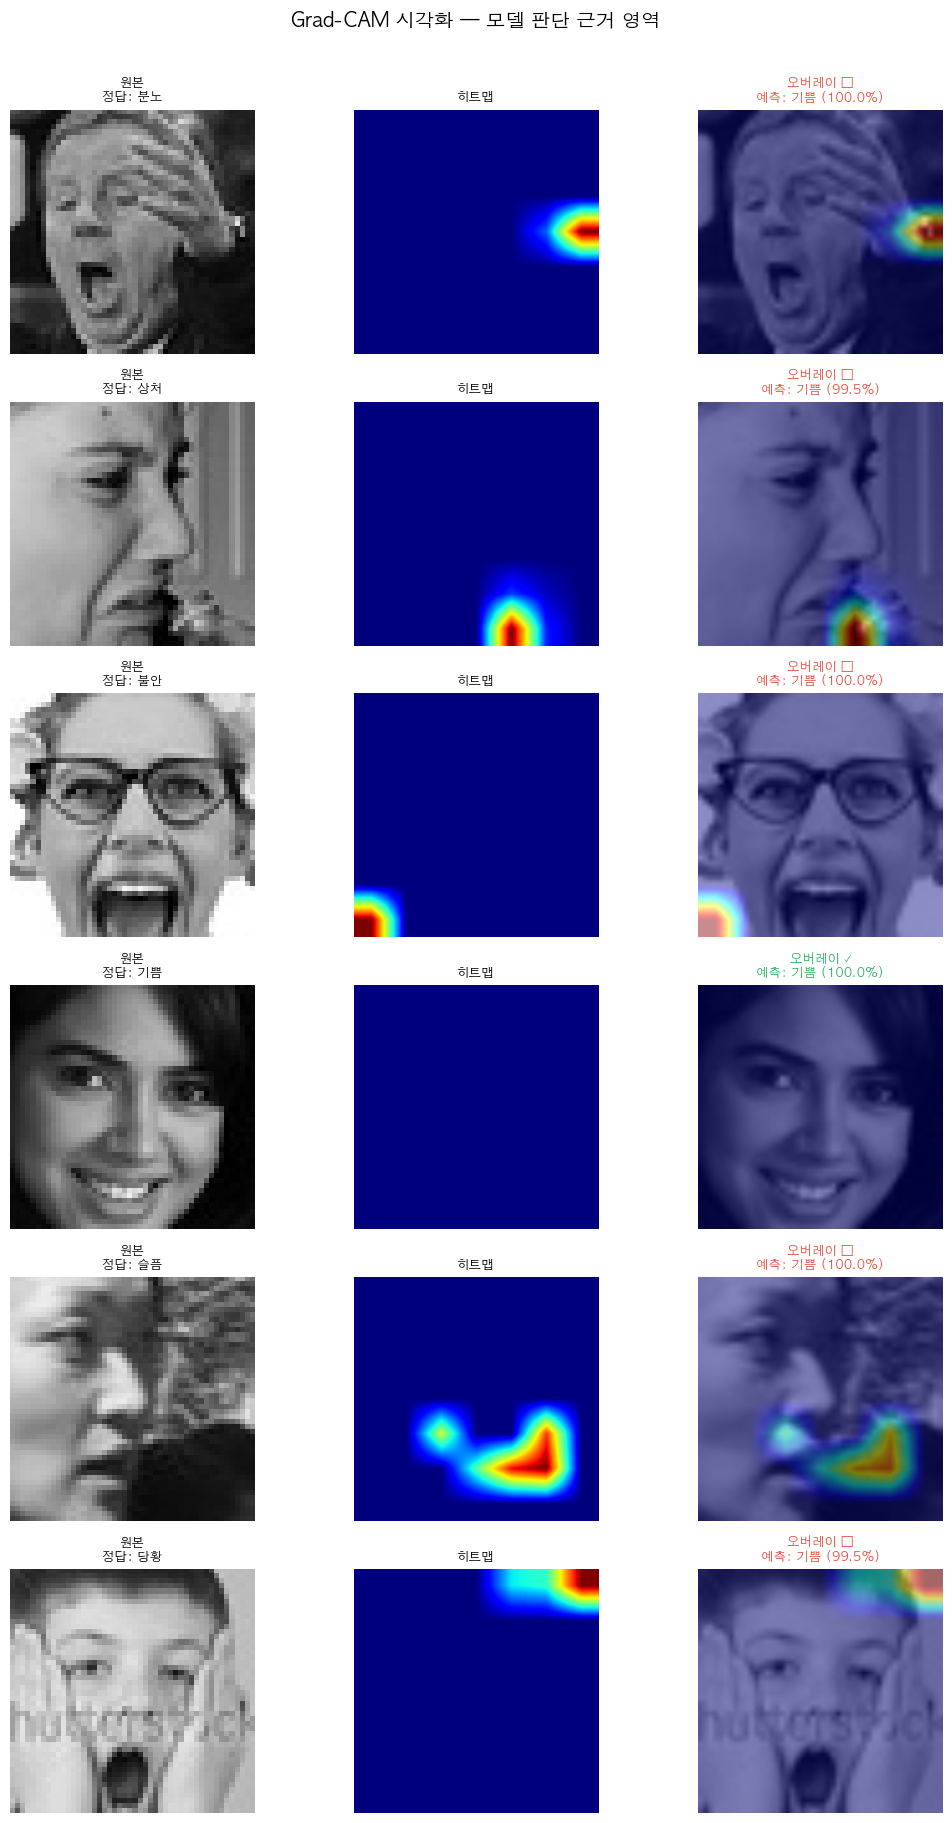

In [18]:
def visualize_gradcam_grid(test_dir, classes, n_per_class=1):
    n_rows = len(classes) * n_per_class
    fig, axes = plt.subplots(n_rows, 3, figsize=(11, n_rows * 3))

    row = 0
    for eng in sorted(classes):
        kor = ENG_TO_KOR[eng]
        cls_dir = os.path.join(test_dir, eng)
        files = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')][:n_per_class]

        for fname in files:
            img_bgr = cv2.imread(os.path.join(cls_dir, fname))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_224 = cv2.resize(img_rgb, IMG_SIZE).astype(np.float32)
            inp     = preprocess_input(np.expand_dims(img_224, 0))

            heatmap, pred_idx, probs = compute_gradcam(inp)
            overlay  = apply_gradcam_overlay(img_224, heatmap)
            pred_kor = IDX_TO_KOR[pred_idx]
            conf     = probs[pred_idx]
            correct  = (pred_kor == kor)
            color    = '#27ae60' if correct else '#e74c3c'
            mark     = '✓' if correct else '✗'

            axes[row][0].imshow(img_rgb)
            axes[row][0].set_title(f'원본\n정답: {kor}', fontsize=9)
            axes[row][0].axis('off')

            axes[row][1].imshow(cv2.resize(heatmap, IMG_SIZE), cmap='jet')
            axes[row][1].set_title('히트맵', fontsize=9)
            axes[row][1].axis('off')

            axes[row][2].imshow(overlay)
            axes[row][2].set_title(
                f'오버레이 {mark}\n예측: {pred_kor} ({conf:.1%})',
                fontsize=9, color=color, fontweight='bold'
            )
            axes[row][2].axis('off')
            row += 1

    plt.suptitle('Grad-CAM 시각화 — 모델 판단 근거 영역',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


visualize_gradcam_grid(TEST_DIR, USE_CLASSES, n_per_class=1)

## 8. 감정 예측 함수

### 방법 1 : 이미지 파일 경로로 예측
### 방법 2 : FER2013 폴더에서 랜덤 샘플 예측

In [19]:
def predict_from_file(img_path):
    """
    방법 1: 이미지 파일로 감정 예측 + Grad-CAM 시각화
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f'이미지를 찾을 수 없습니다: {img_path}')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_224 = cv2.resize(img_rgb, IMG_SIZE).astype(np.float32)
    inp     = preprocess_input(np.expand_dims(img_224, 0))

    probs    = model.predict(inp, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_kor = IDX_TO_KOR[pred_idx]

    heatmap, _, _ = compute_gradcam(inp, pred_index=pred_idx)
    overlay = apply_gradcam_overlay(img_224, heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title('입력 이미지', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title(f'Grad-CAM\n예측: {pred_kor} ({probs[pred_idx]:.1%})',
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')

    colors = ['#e74c3c' if i == pred_idx else '#bdc3c7' for i in range(NUM_CLASSES)]
    bars = axes[2].barh(KOR_CLASSES, probs, color=colors)
    axes[2].set_xlim(0, 1.05)
    axes[2].set_xlabel('확률')
    axes[2].set_title('감정별 예측 확률', fontsize=12)
    for bar, p in zip(bars, probs):
        axes[2].text(p + 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{p:.1%}', va='center', fontsize=10)
    axes[2].spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'예측 결과: {pred_kor}  (신뢰도 {probs[pred_idx]:.1%})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return pred_kor, dict(zip(KOR_CLASSES, probs))


print('사용법: pred, probs = predict_from_file("얼굴이미지.jpg")')

사용법: pred, probs = predict_from_file("얼굴이미지.jpg")


=== 감정별 랜덤 예측 시연 ===

--- 분노 (angry) ---


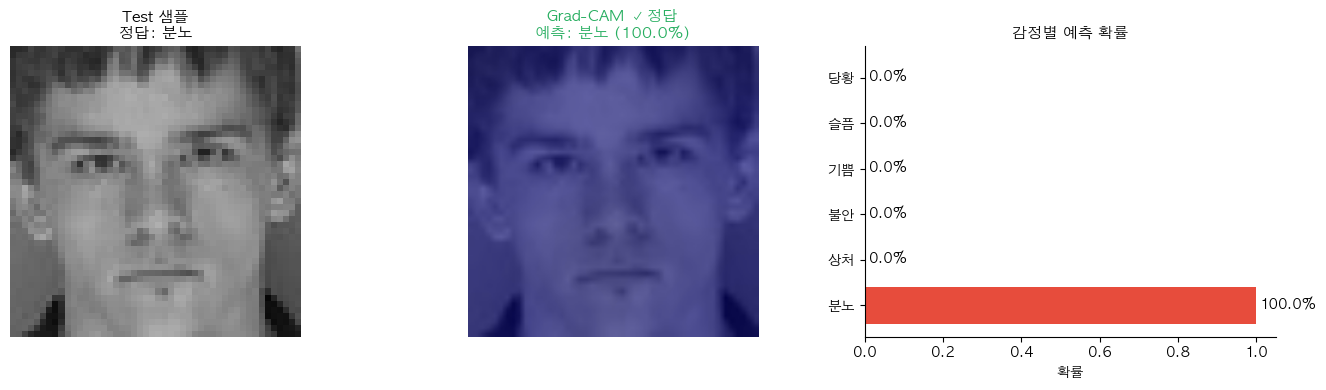

Top-3: 분노:100.0%  불안:0.0%  슬픔:0.0%

--- 상처 (disgust) ---


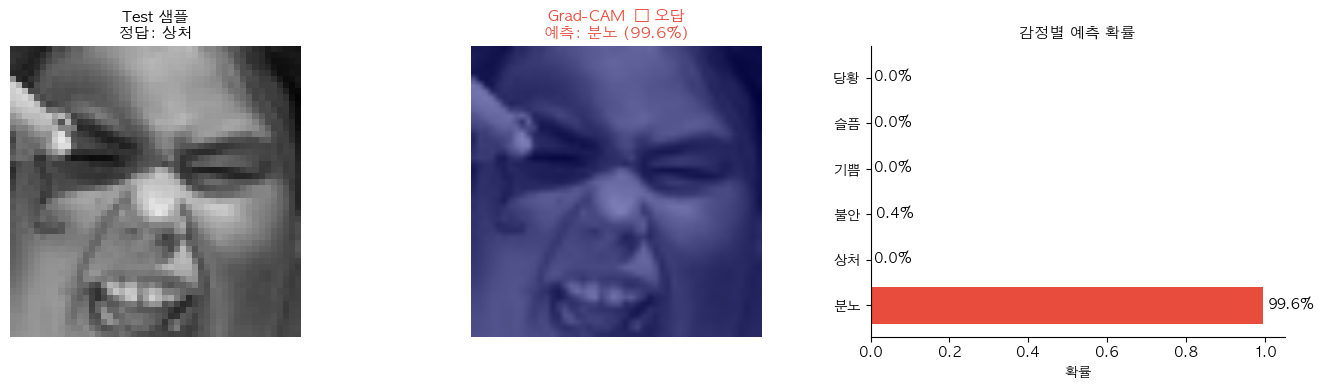

Top-3: 분노:99.6%  불안:0.4%  기쁨:0.0%

--- 불안 (fear) ---


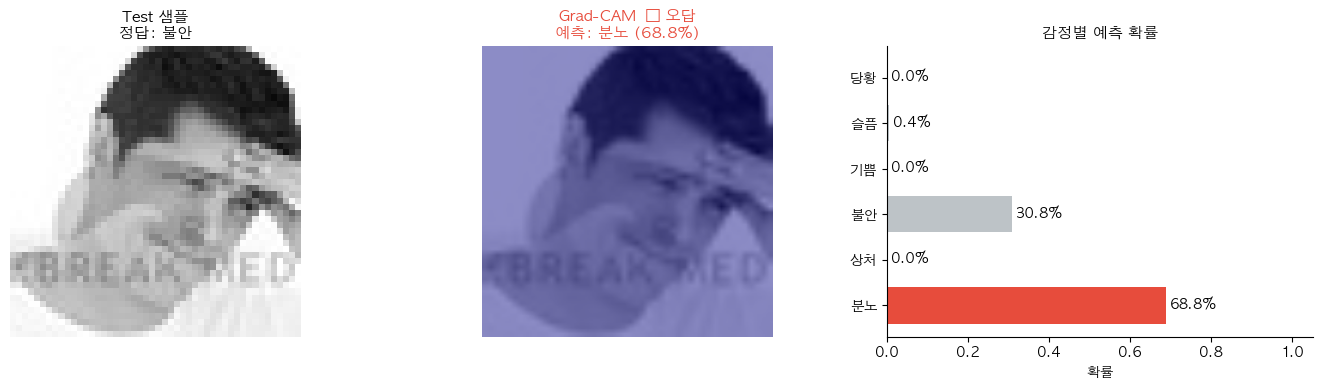

Top-3: 분노:68.8%  불안:30.8%  슬픔:0.4%

--- 기쁨 (happy) ---


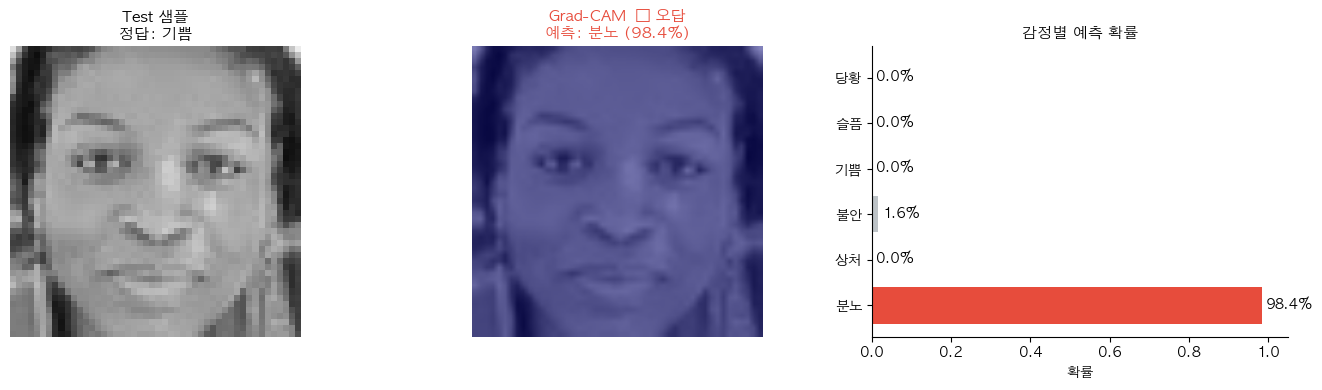

Top-3: 분노:98.4%  불안:1.6%  기쁨:0.0%

--- 슬픔 (sad) ---


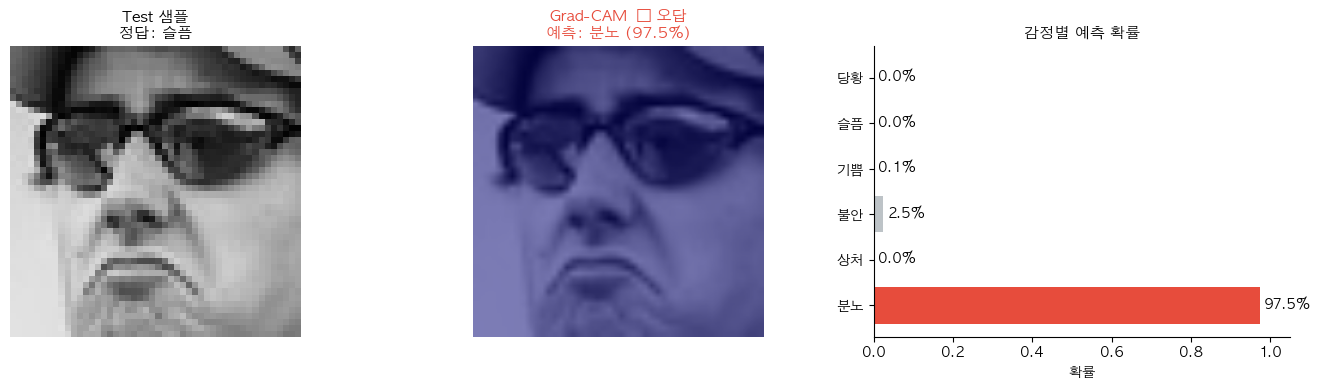

Top-3: 분노:97.5%  불안:2.5%  기쁨:0.1%

--- 당황 (surprise) ---


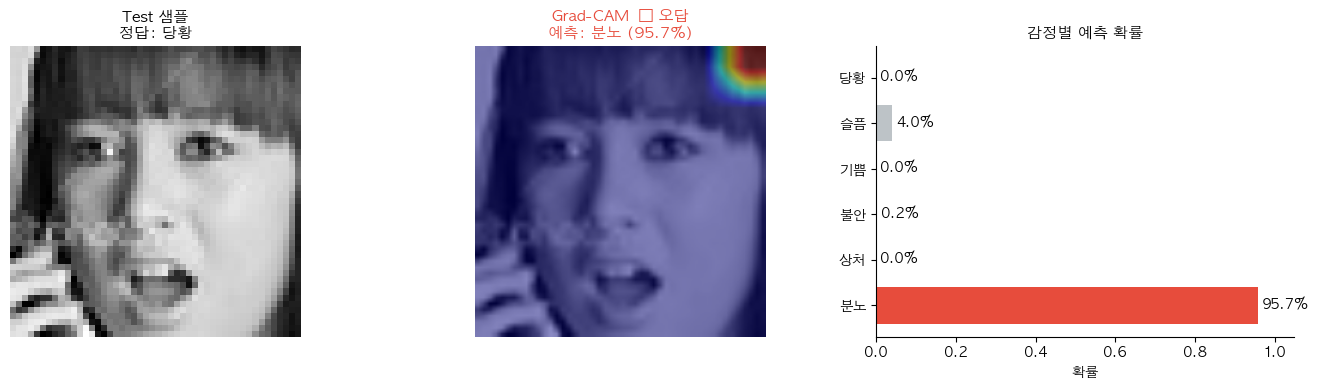

Top-3: 분노:95.7%  슬픔:4.0%  불안:0.2%



In [20]:
def predict_from_test_sample(eng_class=None):
    """
    방법 2: FER2013 test 폴더에서 랜덤 샘플로 예측
    eng_class: 'angry', 'happy' 등 (None이면 전체 랜덤)
    """
    if eng_class is None:
        eng_class = np.random.choice(USE_CLASSES)

    cls_dir = os.path.join(TEST_DIR, eng_class)
    fname   = np.random.choice([f for f in os.listdir(cls_dir) if f.endswith('.jpg')])
    true_kor = ENG_TO_KOR[eng_class]

    img_bgr = cv2.imread(os.path.join(cls_dir, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_224 = cv2.resize(img_rgb, IMG_SIZE).astype(np.float32)
    inp     = preprocess_input(np.expand_dims(img_224, 0))

    probs    = model.predict(inp, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_kor = IDX_TO_KOR[pred_idx]

    heatmap, _, _ = compute_gradcam(inp, pred_index=pred_idx)
    overlay = apply_gradcam_overlay(img_224, heatmap)

    correct = (pred_kor == true_kor)
    mark    = '✓ 정답' if correct else '✗ 오답'
    color   = '#27ae60' if correct else '#e74c3c'

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Test 샘플\n정답: {true_kor}', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title(f'Grad-CAM  {mark}\n예측: {pred_kor} ({probs[pred_idx]:.1%})',
                      fontsize=11, fontweight='bold', color=color)
    axes[1].axis('off')

    colors = ['#e74c3c' if i == pred_idx else '#bdc3c7' for i in range(NUM_CLASSES)]
    bars = axes[2].barh(KOR_CLASSES, probs, color=colors)
    axes[2].set_xlim(0, 1.05)
    axes[2].set_xlabel('확률')
    axes[2].set_title('감정별 예측 확률', fontsize=11)
    for bar, p in zip(bars, probs):
        axes[2].text(p + 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{p:.1%}', va='center', fontsize=10)
    axes[2].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    return pred_kor, dict(zip(KOR_CLASSES, probs))


# 감정별로 각 1장씩 예측 시연
print('=== 감정별 랜덤 예측 시연 ===\n')
for eng in sorted(USE_CLASSES):
    print(f'--- {ENG_TO_KOR[eng]} ({eng}) ---')
    pred_kor, prob_dict = predict_from_test_sample(eng_class=eng)
    top3 = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:3]
    print('Top-3:', '  '.join(f'{e}:{p:.1%}' for e, p in top3))
    print()

## 9. 모델 저장

In [21]:
MODEL_PATH  = 'emotion_6class_efficientnet.keras'
CONFIG_PATH = 'class_config.pkl'

model.save(MODEL_PATH)
print(f'모델 저장 완료 : {MODEL_PATH}')

config = {
    'IDX_TO_KOR':   IDX_TO_KOR,
    'KOR_CLASSES':  KOR_CLASSES,
    'ENG_TO_KOR':   ENG_TO_KOR,
    'USE_CLASSES':  USE_CLASSES,
    'NUM_CLASSES':  NUM_CLASSES,
    'IMG_SIZE':     IMG_SIZE,
}
with open(CONFIG_PATH, 'wb') as f:
    pickle.dump(config, f)
print(f'설정 저장 완료 : {CONFIG_PATH}')

print('\n=== 저장 파일 목록 ===')
for p in [MODEL_PATH, CONFIG_PATH,
          'best_model_phase1.keras', 'best_model_phase2.keras']:
    if os.path.exists(p):
        size = os.path.getsize(p) / 1024 / 1024
        print(f'  {p:40s} {size:.1f} MB')

print('\n=== 모델 로드 예시 ===')
print('import tensorflow as tf, pickle')
print(f'model  = tf.keras.models.load_model("{MODEL_PATH}")')
print(f'config = pickle.load(open("{CONFIG_PATH}", "rb"))')
print('IDX_TO_KOR = config["IDX_TO_KOR"]')

모델 저장 완료 : emotion_6class_efficientnet.keras
설정 저장 완료 : class_config.pkl

=== 저장 파일 목록 ===
  emotion_6class_efficientnet.keras        19.2 MB
  class_config.pkl                         0.0 MB
  best_model_phase1.keras                  19.2 MB
  best_model_phase2.keras                  19.2 MB

=== 모델 로드 예시 ===
import tensorflow as tf, pickle
model  = tf.keras.models.load_model("emotion_6class_efficientnet.keras")
config = pickle.load(open("class_config.pkl", "rb"))
IDX_TO_KOR = config["IDX_TO_KOR"]
